<a href="https://colab.research.google.com/github/MrStranger812/MovieLens-CLI-DM/blob/NotebookGCPP/Notebooks/04_Clustering_Movielens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import pickle
import gzip
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union
import gc
import time

# Sklearn imports
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy import sparse

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Paths
BASE_DIR = Path("/content/drive/MyDrive/Movielens")
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports" / "clustering"
REPORTS_DIR.mkdir(exist_ok=True, parents=True)

print("MovieLens Clustering Pipeline")
print(f"Data directory: {PROCESSED_DATA_DIR}")
print(f"Reports directory: {REPORTS_DIR}")

MovieLens Clustering Pipeline
Data directory: /content/drive/MyDrive/Movielens/data/processed
Reports directory: /content/drive/MyDrive/Movielens/reports/clustering


In [3]:
def load_preprocessed_data():
    """Load preprocessed data from the pipeline outputs."""
    print("\n=== Loading Preprocessed Data ===")
    data = {}

    # Priority 1: Load from ML-ready datasets if available
    ml_datasets_path = PROCESSED_DATA_DIR / "ml_ready_datasets.pkl.gz"
    if ml_datasets_path.exists():
        print(f"Loading ML-ready datasets from {ml_datasets_path.name}")
        try:
            with gzip.open(ml_datasets_path, 'rb') as f:
                ml_datasets = pickle.load(f)
            data['ml_datasets'] = ml_datasets
            print(f"  ✓ Loaded ML datasets: {list(ml_datasets.keys())}")
        except Exception as e:
            print(f"  ✗ Error loading ML datasets: {e}")

    # Priority 2: Load feature files
    feature_files = {
        'user_features': ['user_features.parquet', 'user_features.csv'],
        'movie_features': ['movie_features.parquet', 'movie_features.csv'],
        'ratings': ['ratings_cleaned.csv', 'ratings.parquet'],
        'movies': ['movies_cleaned.csv', 'movies.parquet']
    }

    for key, filenames in feature_files.items():
        for filename in filenames:
            filepath = PROCESSED_DATA_DIR / filename
            if filepath.exists():
                try:
                    if filename.endswith('.parquet'):
                        data[key] = pd.read_parquet(filepath)
                    else:
                        data[key] = pd.read_csv(filepath)
                    print(f"  ✓ Loaded {key}: {data[key].shape}")
                    break
                except Exception as e:
                    print(f"  ✗ Error loading {filename}: {e}")

    # Load sparse matrices if available
    sparse_files = {
        'user_item_matrix': 'user_item_matrix.npz',
        'tfidf_matrix': 'tfidf_matrix.npz'
    }

    for key, filename in sparse_files.items():
        filepath = PROCESSED_DATA_DIR / filename
        if filepath.exists():
            try:
                data[key] = sparse.load_npz(filepath)
                print(f"  ✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"  ✗ Error loading {filename}: {e}")

    # Load mappings
    mappings_path = PROCESSED_DATA_DIR / "user_item_mappings.pkl"
    if mappings_path.exists():
        try:
            with open(mappings_path, 'rb') as f:
                user_mapping, movie_mapping = pickle.load(f)
                data['user_mapping'] = user_mapping
                data['movie_mapping'] = movie_mapping
                print(f"  ✓ Loaded mappings: {len(user_mapping)} users, {len(movie_mapping)} movies")
        except Exception as e:
            print(f"  ✗ Error loading mappings: {e}")

    return data

def validate_data(data):
    """Validate loaded data and report any issues."""
    print("\n=== Data Validation ===")
    required_for_clustering = ['user_features', 'movie_features']

    missing = []
    for key in required_for_clustering:
        if key not in data or data[key] is None:
            missing.append(key)

    if missing:
        print(f"  ⚠ Missing required data: {missing}")
        print("  Attempting to reconstruct from available data...")

        # Try to reconstruct from ML datasets
        if 'ml_datasets' in data:
            if 'user_features' not in data and 'clustering_users' in data['ml_datasets']:
                data['user_features'] = data['ml_datasets']['clustering_users']['X']
                print("  ✓ Reconstructed user_features from ML datasets")

            if 'movie_features' not in data and 'clustering_movies' in data['ml_datasets']:
                data['movie_features'] = data['ml_datasets']['clustering_movies']['X']
                print("  ✓ Reconstructed movie_features from ML datasets")

    # Data quality checks
    for key in ['user_features', 'movie_features']:
        if key in data and data[key] is not None:
            df = data[key]
            print(f"\n{key}:")
            print(f"  Shape: {df.shape}")
            print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
            print(f"  Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")

            # Check for issues
            nan_cols = df.isna().sum()
            if nan_cols.any():
                print(f"  ⚠ Columns with NaN: {nan_cols[nan_cols > 0].to_dict()}")

    return data


In [4]:
class UserSegmentation:
    """User segmentation based on rating behaviors and preferences."""

    def __init__(self, n_clusters=8, method='kmeans', random_state=42):
        self.n_clusters = n_clusters
        self.method = method
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.pca = None
        self.model = None
        self.user_features = None
        self.user_clusters = None
        self.cluster_profiles = None

    def prepare_features(self, user_features_df):
        """Prepare and validate user features for clustering."""
        print(f"\nPreparing user features ({user_features_df.shape[0]} users)...")

        # Select only numeric features
        numeric_features = user_features_df.select_dtypes(include=[np.number])

        # Remove constant features
        constant_cols = [col for col in numeric_features.columns
                        if numeric_features[col].nunique() <= 1]
        if constant_cols:
            print(f"  Removing {len(constant_cols)} constant features")
            numeric_features = numeric_features.drop(columns=constant_cols)

        # Handle missing values
        numeric_features = numeric_features.fillna(0)

        # Remove highly correlated features (correlation > 0.95)
        corr_matrix = numeric_features.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_drop = [column for column in upper_triangle.columns
                  if any(upper_triangle[column] > 0.95)]
        if to_drop:
            print(f"  Removing {len(to_drop)} highly correlated features")
            numeric_features = numeric_features.drop(columns=to_drop)

        self.user_features = numeric_features
        self.feature_names = list(numeric_features.columns)
        print(f"  Final features: {len(self.feature_names)} features")

        return self.user_features

    def fit_clusters(self, apply_pca=True, n_components=20):
        """Fit clustering model to user features."""
        if self.user_features is None:
            raise ValueError("No features prepared. Run prepare_features first.")

        print(f"\nFitting {self.method} clustering with {self.n_clusters} clusters...")

        # Scale features
        X_scaled = self.scaler.fit_transform(self.user_features)

        # Apply PCA if requested
        if apply_pca and X_scaled.shape[1] > n_components:
            self.pca = PCA(n_components=n_components, random_state=self.random_state)
            X_scaled = self.pca.fit_transform(X_scaled)
            explained_var = self.pca.explained_variance_ratio_.sum()
            print(f"  PCA: {n_components} components ({explained_var:.1%} variance)")

        # Fit clustering model
        if self.method == 'kmeans':
            # Use MiniBatchKMeans for large datasets
            if len(X_scaled) > 10000:
                self.model = MiniBatchKMeans(
                    n_clusters=self.n_clusters,
                    random_state=self.random_state,
                    batch_size=1024,
                    n_init=10
                )
            else:
                self.model = KMeans(
                    n_clusters=self.n_clusters,
                    random_state=self.random_state,
                    n_init=10
                )
            self.user_clusters = self.model.fit_predict(X_scaled)

        elif self.method == 'agglomerative':
            if len(X_scaled) > 10000:
                print("  Warning: Agglomerative clustering on large dataset may be slow")
            self.model = AgglomerativeClustering(
                n_clusters=self.n_clusters,
                linkage='ward'
            )
            self.user_clusters = self.model.fit_predict(X_scaled)

        # Calculate metrics
        try:
            metrics = {
                'silhouette': silhouette_score(X_scaled, self.user_clusters),
                'davies_bouldin': davies_bouldin_score(X_scaled, self.user_clusters),
                'calinski_harabasz': calinski_harabasz_score(X_scaled, self.user_clusters)
            }
            print(f"  Silhouette Score: {metrics['silhouette']:.3f}")
            print(f"  Davies-Bouldin Score: {metrics['davies_bouldin']:.3f}")
            print(f"  Calinski-Harabasz Score: {metrics['calinski_harabasz']:.1f}")
        except:
            metrics = {}

        # Add cluster labels to features
        self.user_features['cluster'] = self.user_clusters

        # Calculate cluster profiles
        self._calculate_cluster_profiles()

        return metrics

    def _calculate_cluster_profiles(self):
        """Calculate statistical profiles for each cluster."""
        self.cluster_profiles = self.user_features.groupby('cluster').agg(['mean', 'std', 'count'])

        # Create interpretable labels based on feature patterns
        self.cluster_labels = []
        for cluster_id in range(self.n_clusters):
            cluster_data = self.user_features[self.user_features['cluster'] == cluster_id]

            # Analyze key characteristics
            size = len(cluster_data)

            # Try to find distinguishing features
            feature_means = cluster_data.mean()
            overall_means = self.user_features.mean()

            # Find most distinctive feature
            relative_diff = ((feature_means - overall_means) / (overall_means + 1e-8)).abs()
            top_feature = relative_diff.nlargest(3).index.tolist()

            label = f"Cluster {cluster_id} (n={size})"
            self.cluster_labels.append((cluster_id, label, size))

    def get_cluster_summary(self):
        """Get a summary DataFrame of clusters."""
        if self.cluster_profiles is None:
            return None

        summary = []
        for cluster_id, label, size in self.cluster_labels:
            # FIX 1: Use .loc to select the row by its index label (cluster_id).
            cluster_stats = self.cluster_profiles.loc[cluster_id]

            # The result 'cluster_stats' is a Series with a MultiIndex.
            # Now we can extract the 'mean' values from its index.

            # FIX 2: Select the 'mean' stats from the Series.
            # The axis is implicitly 0 for a Series.
            means = cluster_stats.xs('mean', level=1)

            # The rest of the logic works perfectly with this fix.
            top_features = means.nlargest(3).index.tolist()

            summary.append({
                'cluster': cluster_id,
                'size': size,
                'label': label,
                'top_features': ', '.join(top_features[:3])
            })

        return pd.DataFrame(summary)

    def plot_clusters(self, save_path=None):
        """Visualize user clusters."""
        if self.pca is None:
            # Apply PCA for visualization
            pca_viz = PCA(n_components=2, random_state=self.random_state)
            X_scaled = self.scaler.transform(self.user_features.drop('cluster', axis=1))
            X_2d = pca_viz.fit_transform(X_scaled)
        else:
            # Use existing PCA
            X_scaled = self.scaler.transform(self.user_features.drop('cluster', axis=1))
            X_2d = self.pca.transform(X_scaled)[:, :2]

        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        # Scatter plot
        scatter = ax1.scatter(X_2d[:, 0], X_2d[:, 1],
                             c=self.user_clusters,
                             cmap='tab10', alpha=0.6, s=20)

        # Add cluster centers
        for cluster_id in range(self.n_clusters):
            mask = self.user_clusters == cluster_id
            if mask.any():
                center = X_2d[mask].mean(axis=0)
                ax1.scatter(center[0], center[1], c='black', s=200,
                          marker='*', edgecolors='white', linewidth=2)
                ax1.annotate(f'{cluster_id}', xy=center, xytext=(5, 5),
                           textcoords='offset points', fontsize=12, fontweight='bold')

        ax1.set_xlabel('First Principal Component')
        ax1.set_ylabel('Second Principal Component')
        ax1.set_title(f'User Segmentation - {self.method.title()}')
        ax1.grid(True, alpha=0.3)

        # Cluster sizes
        cluster_sizes = pd.Series(self.user_clusters).value_counts().sort_index()
        ax2.bar(range(self.n_clusters), cluster_sizes.values)
        ax2.set_xlabel('Cluster ID')
        ax2.set_ylabel('Number of Users')
        ax2.set_title('Cluster Size Distribution')
        ax2.set_xticks(range(self.n_clusters))

        for i, v in enumerate(cluster_sizes.values):
            ax2.text(i, v + max(cluster_sizes.values)*0.01, str(v),
                    ha='center', va='bottom')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        else:
            plt.savefig(REPORTS_DIR / f'user_segmentation_{self.method}.png',
                       dpi=150, bbox_inches='tight')
        plt.show()

In [5]:
class ClusteringComparison:
    """Compare different clustering configurations and methods."""

    def __init__(self, use_gpu: bool = False):
        self.use_gpu = use_gpu and CUML_AVAILABLE
        self.console = Console()
        self.results = {}

    def compare_kmeans_configurations(self, features: pd.DataFrame,
                                    k_range: range = range(3, 16),
                                    n_init: int = 10):
        """Compare different K values for K-means clustering."""
        self.console.print(Panel.fit(
            "[bold cyan]K-Means Clustering Comparison[/bold cyan]\n"
            "Finding optimal number of clusters",
            border_style="cyan"
        ))

        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)

        results = []

        with Progress(
            SpinnerColumn(),
            TextColumn("[progress.description]{task.description}"),
            BarColumn(),
            console=self.console
        ) as progress:
            task = progress.add_task("[cyan]Testing K values...", total=len(k_range))

            for k in k_range:
                if self.use_gpu:
                    kmeans = cuKMeans(n_clusters=k, random_state=42)
                    labels = kmeans.fit_predict(features_scaled)
                else:
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init=n_init)
                    labels = kmeans.fit_predict(features_scaled)

                # Calculate metrics
                silhouette = silhouette_score(features_scaled, labels)
                davies_bouldin = davies_bouldin_score(features_scaled, labels)
                calinski = calinski_harabasz_score(features_scaled, labels)

                # Calculate inertia (within-cluster sum of squares)
                if hasattr(kmeans, 'inertia_'):
                    inertia = kmeans.inertia_
                else:
                    # Calculate manually for GPU version
                    inertia = 0
                    for i in range(k):
                        cluster_points = features_scaled[labels == i]
                        if len(cluster_points) > 0:
                            center = cluster_points.mean(axis=0)
                            inertia += ((cluster_points - center) ** 2).sum()

                results.append({
                    'k': k,
                    'silhouette': silhouette,
                    'davies_bouldin': davies_bouldin,
                    'calinski_harabasz': calinski,
                    'inertia': inertia
                })

                progress.advance(task)

        self.kmeans_results = pd.DataFrame(results)
        self._display_kmeans_results()
        self._plot_elbow_curve()

        return self.kmeans_results

    def _display_kmeans_results(self):
        """Display K-means comparison results."""
        # Find best K based on silhouette score
        best_k = self.kmeans_results.loc[self.kmeans_results['silhouette'].idxmax(), 'k']

        self.console.print(
            f"\n[bold green]Optimal K based on Silhouette Score: {int(best_k)}[/bold green]"
        )

        # Create results table
        table = Table(title="K-Means Clustering Metrics", box=box.ROUNDED)
        table.add_column("K", style="cyan", justify="right")
        table.add_column("Silhouette ↑", justify="right", style="green")
        table.add_column("Davies-Bouldin ↓", justify="right", style="yellow")
        table.add_column("Calinski-Harabasz ↑", justify="right", style="blue")

        for _, row in self.kmeans_results.iterrows():
            k_display = f"[bold]{int(row['k'])}[/bold]" if row['k'] == best_k else str(int(row['k']))

            table.add_row(
                k_display,
                f"{row['silhouette']:.3f}",
                f"{row['davies_bouldin']:.3f}",
                f"{row['calinski_harabasz']:.1f}"
            )

        self.console.print(table)

    def _plot_elbow_curve(self, save_path: Optional[Path] = None):
        """Plot elbow curve and silhouette scores."""
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

        k_values = self.kmeans_results['k'].values

        # Elbow curve
        ax1.plot(k_values, self.kmeans_results['inertia'], 'bo-', linewidth=2, markersize=8)
        ax1.set_xlabel('Number of Clusters (K)')
        ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
        ax1.set_title('Elbow Curve')
        ax1.grid(True, alpha=0.3)

        # Silhouette scores
        ax2.plot(k_values, self.kmeans_results['silhouette'], 'go-', linewidth=2, markersize=8)
        best_k = self.kmeans_results.loc[self.kmeans_results['silhouette'].idxmax(), 'k']
        best_silhouette = self.kmeans_results['silhouette'].max()
        ax2.scatter([best_k], [best_silhouette], color='red', s=200, zorder=5)
        ax2.set_xlabel('Number of Clusters (K)')
        ax2.set_ylabel('Silhouette Score')
        ax2.set_title('Silhouette Score vs K')
        ax2.grid(True, alpha=0.3)

        # Davies-Bouldin scores
        ax3.plot(k_values, self.kmeans_results['davies_bouldin'], 'ro-', linewidth=2, markersize=8)
        ax3.set_xlabel('Number of Clusters (K)')
        ax3.set_ylabel('Davies-Bouldin Score')
        ax3.set_title('Davies-Bouldin Score vs K (Lower is Better)')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        else:
            plt.savefig(REPORTS_DIR / 'kmeans_comparison.png', dpi=300, bbox_inches='tight')
        plt.close()

        self.console.print("[green]✓ Elbow curve and metrics plots saved[/green]")

    def compare_linkage_methods(self, features: pd.DataFrame,
                               linkage_methods: List[str] = ['ward', 'complete', 'average'],
                               n_clusters_range: range = range(5, 21, 5)):
        """Compare different linkage methods for hierarchical clustering."""
        self.console.print(Panel.fit(
            "[bold cyan]Hierarchical Clustering Comparison[/bold cyan]\n"
            "Comparing different linkage methods",
            border_style="cyan"
        ))

        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)

        # Limit size for hierarchical clustering
        if len(features_scaled) > 5000:
            self.console.print(
                "[yellow]Sampling 5000 movies for hierarchical comparison[/yellow]"
            )
            sample_idx = np.random.choice(len(features_scaled), 5000, replace=False)
            features_scaled = features_scaled[sample_idx]

        results = {}

        with Progress(
            SpinnerColumn(),
            TextColumn("[progress.description]{task.description}"),
            BarColumn(),
            console=self.console
        ) as progress:
            total = len(linkage_methods) * len(n_clusters_range)
            task = progress.add_task("[cyan]Comparing configurations...", total=total)

            for linkage_method in linkage_methods:
                results[linkage_method] = {}

                # Compute linkage once for each method
                linkage_matrix = linkage(features_scaled, method=linkage_method)

                for n_clusters in n_clusters_range:
                    # Get clusters
                    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

                    # Calculate metrics
                    silhouette = silhouette_score(features_scaled, clusters)
                    davies_bouldin = davies_bouldin_score(features_scaled, clusters)
                    calinski = calinski_harabasz_score(features_scaled, clusters)

                    results[linkage_method][n_clusters] = {
                        'silhouette': silhouette,
                        'davies_bouldin': davies_bouldin,
                        'calinski_harabasz': calinski,
                        'n_clusters_actual': len(np.unique(clusters))
                    }

                    progress.advance(task)

        self.hierarchical_results = results
        self._display_hierarchical_results()

        return results

    def _display_hierarchical_results(self):
        """Display hierarchical clustering comparison results."""
        # Find best configuration
        best_config = None
        best_silhouette = -1

        for linkage_method, clusters_results in self.hierarchical_results.items():
            for n_clusters, metrics in clusters_results.items():
                if metrics['silhouette'] > best_silhouette:
                    best_silhouette = metrics['silhouette']
                    best_config = (linkage_method, n_clusters)

        self.console.print(
            f"\n[bold green]Best Configuration:[/bold green]\n"
            f"Linkage: {best_config[0]}, Clusters: {best_config[1]}\n"
            f"Silhouette Score: {best_silhouette:.3f}"
        )

        # Create comparison table
        table = Table(title="Hierarchical Clustering Results", box=box.ROUNDED)
        table.add_column("Linkage", style="cyan")
        table.add_column("Clusters", justify="right")
        table.add_column("Silhouette ↑", justify="right", style="green")
        table.add_column("Davies-Bouldin ↓", justify="right", style="yellow")
        table.add_column("Calinski-Harabasz ↑", justify="right", style="blue")

        for linkage_method in self.hierarchical_results:
            for n_clusters in sorted(self.hierarchical_results[linkage_method].keys()):
                metrics = self.hierarchical_results[linkage_method][n_clusters]

                # Highlight best configuration
                if (linkage_method, n_clusters) == best_config:
                    linkage_display = f"[bold]{linkage_method}[/bold]"
                else:
                    linkage_display = linkage_method

                table.add_row(
                    linkage_display,
                    str(n_clusters),
                    f"{metrics['silhouette']:.3f}",
                    f"{metrics['davies_bouldin']:.3f}",
                    f"{metrics['calinski_harabasz']:.1f}"
                )

        self.console.print(table)


In [6]:
class MovieClustering:
    """Hierarchical clustering for movies based on features."""

    def __init__(self, linkage_method='ward'):
        self.linkage_method = linkage_method
        self.scaler = StandardScaler()
        self.movie_features = None
        self.movie_features_numeric = None
        self.linkage_matrix = None
        self.clusters = None
        self.cluster_stats = None

    def prepare_features(self, movie_features_df):
        """Prepare movie features for clustering."""
        print(f"\nPreparing movie features ({movie_features_df.shape[0]} movies)...")

        # Select numeric features only
        numeric_features = movie_features_df.select_dtypes(include=[np.number])

        # Remove constant features
        constant_cols = [col for col in numeric_features.columns
                        if numeric_features[col].nunique() <= 1]
        if constant_cols:
            print(f"  Removing {len(constant_cols)} constant features")
            numeric_features = numeric_features.drop(columns=constant_cols)

        # Handle missing values
        numeric_features = numeric_features.fillna(0)

        self.movie_features = movie_features_df
        self.movie_features_numeric = numeric_features
        print(f"  Final features: {len(numeric_features.columns)} features")

        return self.movie_features_numeric

    def fit_hierarchical(self, n_clusters=None, max_samples=5000):
        """Fit hierarchical clustering model."""
        if self.movie_features_numeric is None:
            raise ValueError("No features prepared. Run prepare_features first.")

        print(f"\nPerforming hierarchical clustering ({self.linkage_method} linkage)...")

        # Scale features
        X_scaled = self.scaler.fit_transform(self.movie_features_numeric)

        # Sample if dataset is too large
        if len(X_scaled) > max_samples:
            print(f"  Sampling {max_samples} movies for hierarchical clustering")
            sample_idx = np.random.choice(len(X_scaled), max_samples, replace=False)
            X_sampled = X_scaled[sample_idx]
            self.sample_idx = sample_idx
        else:
            X_sampled = X_scaled
            self.sample_idx = None

        # Compute linkage matrix
        self.linkage_matrix = linkage(X_sampled, method=self.linkage_method)

        # Determine clusters
        if n_clusters is None:
            n_clusters = self._find_optimal_clusters()

        self.clusters = fcluster(self.linkage_matrix, n_clusters, criterion='maxclust')

        # Map clusters back to full dataset if sampled
        if self.sample_idx is not None:
            full_clusters = np.zeros(len(self.movie_features_numeric), dtype=int)
            full_clusters[self.sample_idx] = self.clusters
            # Assign unsampled movies to nearest cluster
            # (simplified - in practice would use KNN or similar)
            unsampled_mask = np.ones(len(full_clusters), dtype=bool)
            unsampled_mask[self.sample_idx] = False
            full_clusters[unsampled_mask] = np.random.randint(1, n_clusters+1,
                                                             sum(unsampled_mask))
            self.clusters = full_clusters

        # Add cluster labels
        self.movie_features['cluster'] = self.clusters

        # Calculate statistics
        self._calculate_cluster_stats()

        print(f"  Created {len(np.unique(self.clusters))} clusters")

        return self.clusters

    def _find_optimal_clusters(self, max_clusters=30):
        """Find optimal number of clusters using elbow method."""
        last = self.linkage_matrix[-max_clusters:, 2]
        acceleration = np.diff(last[::-1], 2)
        k = acceleration.argmax() + 2
        print(f"  Optimal clusters determined: {k}")
        return k

    def _calculate_cluster_stats(self):
        """Calculate statistics for each cluster."""
        stats = []

        for cluster_id in np.unique(self.clusters):
            cluster_movies = self.movie_features[self.movie_features['cluster'] == cluster_id]
            cluster_numeric = self.movie_features_numeric.loc[cluster_movies.index]

            stats.append({
                'cluster_id': cluster_id,
                'size': len(cluster_movies),
                'mean_values': cluster_numeric.mean().to_dict()
            })

        self.cluster_stats = pd.DataFrame(stats)

    def plot_dendrogram(self, save_path=None, max_display=50):
        """Plot dendrogram for hierarchical clustering."""
        if self.linkage_matrix is None:
            print("No linkage matrix available. Run fit_hierarchical first.")
            return

        plt.figure(figsize=(14, 7))

        dendrogram(
            self.linkage_matrix,
            truncate_mode='level',
            p=5,
            leaf_font_size=10,
            show_leaf_counts=True
        )

        plt.title(f'Movie Clustering Dendrogram ({self.linkage_method.title()} Linkage)')
        plt.xlabel('Sample Index or (Cluster Size)')
        plt.ylabel('Distance')
        plt.grid(True, alpha=0.3)

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        else:
            plt.savefig(REPORTS_DIR / f'movie_dendrogram_{self.linkage_method}.png',
                       dpi=150, bbox_inches='tight')
        plt.show()

    def get_cluster_summary(self):
        """Get summary of movie clusters."""
        if self.cluster_stats is None:
            return None

        summary = self.cluster_stats[['cluster_id', 'size']].copy()
        summary = summary.sort_values('size', ascending=False)

        return summary

In [7]:
def perform_cross_analysis(user_clusters, movie_clusters, ratings_df):
    """Analyze how user segments rate movie clusters."""
    print("\n=== Cross-Analysis: User Segments × Movie Clusters ===")

    # Prepare cluster assignments
    user_cluster_map = pd.DataFrame({
        'userId': user_clusters.index,
        'user_cluster': user_clusters['cluster'].values
    })

    movie_cluster_map = pd.DataFrame({
        'movieId': movie_clusters.index,
        'movie_cluster': movie_clusters['cluster'].values
    })

    # Merge with ratings
    cross_df = ratings_df.merge(user_cluster_map, on='userId', how='inner')
    cross_df = cross_df.merge(movie_cluster_map, on='movieId', how='inner')

    # Calculate statistics
    cross_stats = cross_df.groupby(['user_cluster', 'movie_cluster'])['rating'].agg([
        'mean', 'count', 'std'
    ]).round(3)

    # Find significant patterns
    patterns = []
    min_ratings = 100

    for (user_cluster, movie_cluster), stats in cross_stats.iterrows():
        if stats['count'] >= min_ratings:
            if stats['mean'] >= 4.2:
                patterns.append({
                    'user_cluster': user_cluster,
                    'movie_cluster': movie_cluster,
                    'avg_rating': stats['mean'],
                    'count': stats['count'],
                    'pattern': 'Strong Preference'
                })
            elif stats['mean'] <= 2.8:
                patterns.append({
                    'user_cluster': user_cluster,
                    'movie_cluster': movie_cluster,
                    'avg_rating': stats['mean'],
                    'count': stats['count'],
                    'pattern': 'Weak Preference'
                })

    print(f"Found {len(patterns)} significant patterns")

    return cross_stats, patterns

def plot_cross_analysis_heatmap(cross_stats, save_path=None):
    """Create heatmap of cross-analysis results."""
    # Pivot for heatmap
    heatmap_data = cross_stats['mean'].unstack(fill_value=np.nan)

    # Create figure
    plt.figure(figsize=(12, 8))

    # Create heatmap
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=3.5,
        vmin=1,
        vmax=5,
        cbar_kws={'label': 'Average Rating'},
        linewidths=0.5
    )

    plt.xlabel('Movie Cluster')
    plt.ylabel('User Cluster')
    plt.title('Cross-Analysis: How User Segments Rate Movie Clusters')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    else:
        plt.savefig(REPORTS_DIR / 'cross_analysis_heatmap.png',
                   dpi=150, bbox_inches='tight')
    plt.show()


In [8]:
def find_optimal_clusters(features, method='kmeans', k_range=range(3, 16)):
    """Find optimal number of clusters using elbow method and silhouette score."""
    print(f"\nFinding optimal clusters for {method}...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    # Limit samples for efficiency
    if len(X_scaled) > 5000:
        sample_idx = np.random.choice(len(X_scaled), 5000, replace=False)
        X_scaled = X_scaled[sample_idx]

    results = []

    for k in k_range:
        if method == 'kmeans':
            model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
            labels = model.fit_predict(X_scaled)
            inertia = model.inertia_
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage='ward')
            labels = model.fit_predict(X_scaled)
            inertia = 0  # Not applicable for agglomerative

        silhouette = silhouette_score(X_scaled, labels)

        results.append({
            'k': k,
            'silhouette': silhouette,
            'inertia': inertia
        })

        print(f"  k={k}: silhouette={silhouette:.3f}")

    results_df = pd.DataFrame(results)
    optimal_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']

    print(f"  Optimal k: {int(optimal_k)}")

    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Silhouette scores
    ax1.plot(results_df['k'], results_df['silhouette'], 'bo-')
    ax1.axvline(x=optimal_k, color='r', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Number of Clusters')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Silhouette Score vs K')
    ax1.grid(True, alpha=0.3)

    # Elbow curve (for kmeans)
    if method == 'kmeans':
        ax2.plot(results_df['k'], results_df['inertia'], 'go-')
        ax2.set_xlabel('Number of Clusters')
        ax2.set_ylabel('Inertia')
        ax2.set_title('Elbow Curve')
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f'{method}_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()

    return int(optimal_k), results_df

In [9]:
def run_clustering_pipeline():
    """Execute the complete clustering pipeline."""
    print("\n" + "="*50)
    print("MOVIELENS CLUSTERING PIPELINE")
    print("="*50)

    # Step 1: Load preprocessed data
    data = load_preprocessed_data()
    data = validate_data(data)

    if 'user_features' not in data or 'movie_features' not in data:
        print("\n⚠ Critical data missing. Cannot proceed with clustering.")
        return None

    results = {}

    # Step 2: User Segmentation
    print("\n" + "="*50)
    print("PHASE 1: USER SEGMENTATION")
    print("="*50)

    # Find optimal number of clusters
    user_features = data['user_features']
    optimal_k_users, _ = find_optimal_clusters(user_features, method='kmeans', k_range=range(3, 13))

    # Perform user segmentation
    user_seg = UserSegmentation(n_clusters=optimal_k_users, method='kmeans')
    user_seg.prepare_features(user_features)
    user_metrics = user_seg.fit_clusters(apply_pca=True, n_components=20)

    # Display results
    user_summary = user_seg.get_cluster_summary()
    print("\nUser Cluster Summary:")
    print(user_summary)

    # Visualize
    user_seg.plot_clusters()

    results['user_segmentation'] = {
        'model': user_seg,
        'metrics': user_metrics,
        'summary': user_summary
    }

    # Step 3: Movie Clustering
    print("\n" + "="*50)
    print("PHASE 2: MOVIE CLUSTERING")
    print("="*50)

    movie_features = data['movie_features']

    # Perform hierarchical clustering
    movie_clust = MovieClustering(linkage_method='ward')
    movie_clust.prepare_features(movie_features)
    movie_clust.fit_hierarchical(n_clusters=20, max_samples=5000)

    # Display results
    movie_summary = movie_clust.get_cluster_summary()
    print("\nMovie Cluster Summary (Top 10):")
    print(movie_summary.head(10))

    # Visualize
    movie_clust.plot_dendrogram()

    results['movie_clustering'] = {
        'model': movie_clust,
        'summary': movie_summary
    }

    # Step 4: Cross-Analysis (if ratings data available)
    if 'ratings' in data and data['ratings'] is not None:
        print("\n" + "="*50)
        print("PHASE 3: CROSS-ANALYSIS")
        print("="*50)

        cross_stats, patterns = perform_cross_analysis(
            user_seg.user_features,
            movie_clust.movie_features,
            data['ratings']
        )

        # Visualize
        plot_cross_analysis_heatmap(cross_stats)

        # Display top patterns
        if patterns:
            print("\nTop Preference Patterns:")
            patterns_df = pd.DataFrame(patterns).sort_values('count', ascending=False).head(10)
            print(patterns_df)

        results['cross_analysis'] = {
            'stats': cross_stats,
            'patterns': patterns
        }

    # Step 5: Save results
    print("\n" + "="*50)
    print("SAVING RESULTS")
    print("="*50)

    save_results(results)

    return results

def save_results(results):
    """Save clustering results to disk."""
    try:
        # Prepare serializable results
        save_data = {
            'timestamp': pd.Timestamp.now(),
            'user_segmentation': {
                'n_clusters': results['user_segmentation']['model'].n_clusters,
                'method': results['user_segmentation']['model'].method,
                'metrics': results['user_segmentation']['metrics'],
                'summary': results['user_segmentation']['summary'].to_dict('records')
            },
            'movie_clustering': {
                'linkage_method': results['movie_clustering']['model'].linkage_method,
                'n_clusters': len(np.unique(results['movie_clustering']['model'].clusters)),
                'summary': results['movie_clustering']['summary'].to_dict('records')
            }
        }

        if 'cross_analysis' in results:
            save_data['cross_analysis'] = {
                'n_patterns': len(results['cross_analysis']['patterns']),
                'top_patterns': results['cross_analysis']['patterns'][:10] if results['cross_analysis']['patterns'] else []
            }

        # Save to pickle
        output_path = PROCESSED_DATA_DIR / 'clustering_results.pkl.gz'
        with gzip.open(output_path, 'wb') as f:
            pickle.dump(save_data, f, protocol=4)

        print(f"✓ Results saved to {output_path}")

        # Save cluster assignments
        user_clusters_path = PROCESSED_DATA_DIR / 'user_clusters.csv'
        results['user_segmentation']['model'].user_features[['cluster']].to_csv(user_clusters_path)
        print(f"✓ User clusters saved to {user_clusters_path}")

        movie_clusters_path = PROCESSED_DATA_DIR / 'movie_clusters.csv'
        results['movie_clustering']['model'].movie_features[['cluster']].to_csv(movie_clusters_path)
        print(f"✓ Movie clusters saved to {movie_clusters_path}")

    except Exception as e:
        print(f"✗ Error saving results: {e}")


MOVIELENS CLUSTERING PIPELINE

=== Loading Preprocessed Data ===
  ✓ Loaded user_features: (138493, 5)
  ✓ Loaded movie_features: (27278, 9)
  ✓ Loaded user_item_matrix: (138493, 26744)

=== Data Validation ===

user_features:
  Shape: (138493, 5)
  Memory usage: 4.75 MB
  Numeric columns: 5

movie_features:
  Shape: (27278, 9)
  Memory usage: 8.24 MB
  Numeric columns: 6
  ⚠ Columns with NaN: {'year': 229}

PHASE 1: USER SEGMENTATION

Finding optimal clusters for kmeans...
  k=3: silhouette=0.194
  k=4: silhouette=0.236
  k=5: silhouette=0.202
  k=6: silhouette=0.206
  k=7: silhouette=0.211
  k=8: silhouette=0.201
  k=9: silhouette=0.195
  k=10: silhouette=0.199
  k=11: silhouette=0.194
  k=12: silhouette=0.180
  Optimal k: 4


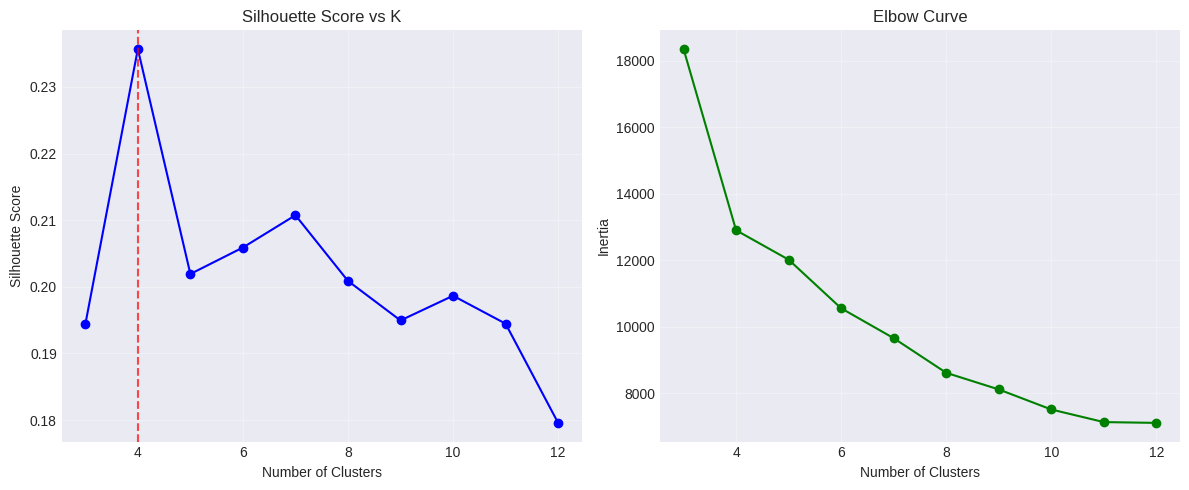


Preparing user features (138493 users)...
  Removing 1 highly correlated features
  Final features: 4 features

Fitting kmeans clustering with 4 clusters...
  Silhouette Score: 0.254
  Davies-Bouldin Score: 1.181
  Calinski-Harabasz Score: 42795.6

User Cluster Summary:
   cluster   size                label                       top_features
0        0   8235   Cluster 0 (n=8235)  userId, rating_count, rating_mean
1        1  47718  Cluster 1 (n=47718)  userId, rating_count, rating_mean
2        2  33985  Cluster 2 (n=33985)  userId, rating_count, rating_mean
3        3  48555  Cluster 3 (n=48555)  userId, rating_count, rating_mean


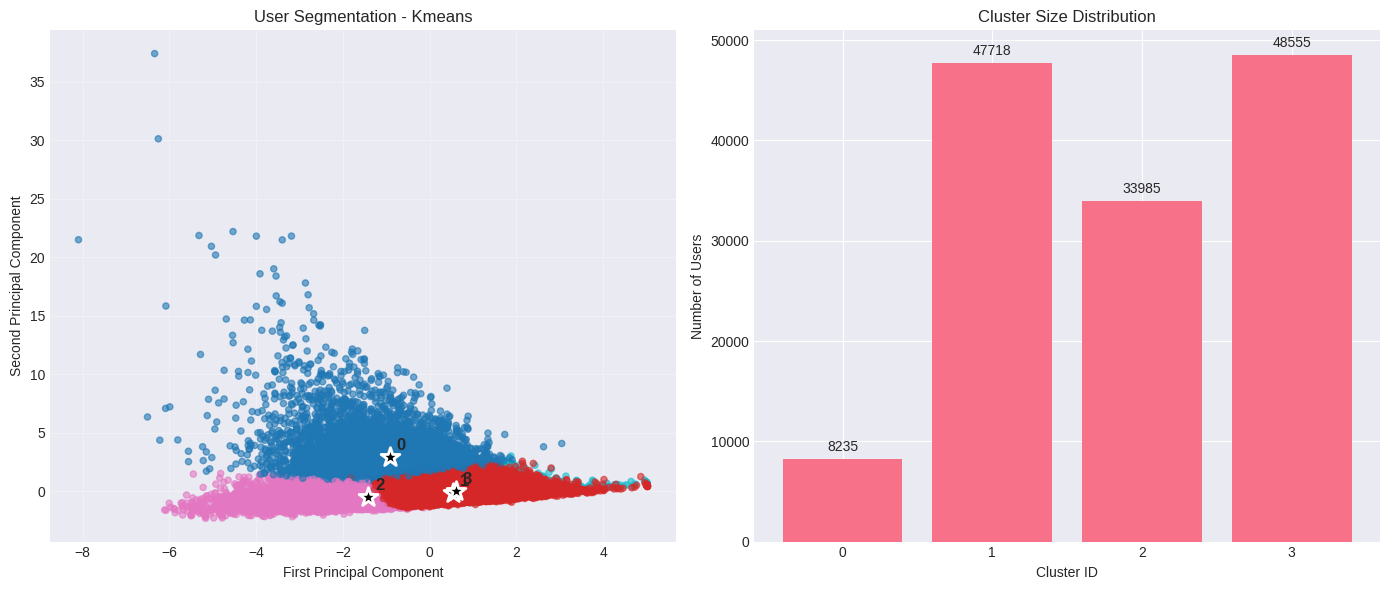


PHASE 2: MOVIE CLUSTERING

Preparing movie features (27278 movies)...
  Final features: 6 features

Performing hierarchical clustering (ward linkage)...
  Sampling 5000 movies for hierarchical clustering
  Created 20 clusters

Movie Cluster Summary (Top 10):
    cluster_id  size
3            4  1889
10          11  1619
12          13  1597
13          14  1561
8            9  1525
17          18  1454
19          20  1446
4            5  1414
9           10  1361
11          12  1356


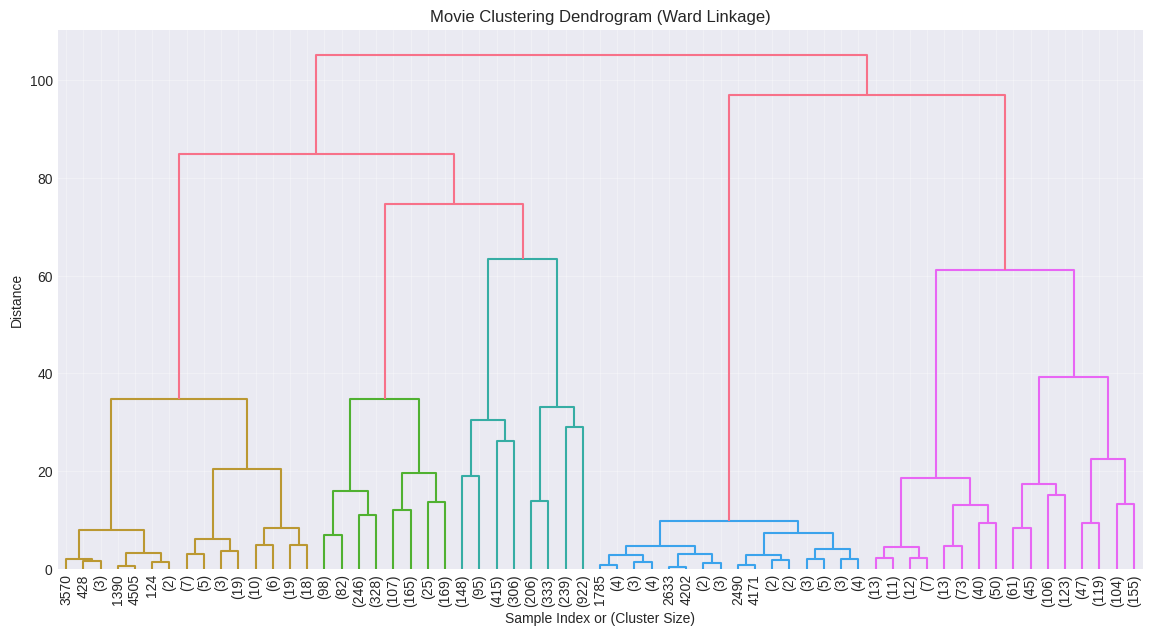


SAVING RESULTS
✓ Results saved to /content/drive/MyDrive/Movielens/data/processed/clustering_results.pkl.gz
✓ User clusters saved to /content/drive/MyDrive/Movielens/data/processed/user_clusters.csv
✓ Movie clusters saved to /content/drive/MyDrive/Movielens/data/processed/movie_clusters.csv

CLUSTERING PIPELINE COMPLETED SUCCESSFULLY

Summary:
• User Segmentation: 4 clusters
• Movie Clustering: 20 clusters

All results saved to: /content/drive/MyDrive/Movielens/data/processed
Visualizations saved to: /content/drive/MyDrive/Movielens/reports/clustering


In [10]:
if __name__ == "__main__":
    # Run the pipeline
    results = run_clustering_pipeline()

    if results:
        print("\n" + "="*50)
        print("CLUSTERING PIPELINE COMPLETED SUCCESSFULLY")
        print("="*50)
        print("\nSummary:")
        print(f"• User Segmentation: {results['user_segmentation']['model'].n_clusters} clusters")
        print(f"• Movie Clustering: {len(np.unique(results['movie_clustering']['model'].clusters))} clusters")
        if 'cross_analysis' in results:
            print(f"• Cross-Analysis: {len(results['cross_analysis']['patterns'])} significant patterns")
        print(f"\nAll results saved to: {PROCESSED_DATA_DIR}")
        print(f"Visualizations saved to: {REPORTS_DIR}")
    else:
        print("\n⚠ Pipeline completed with warnings. Check logs above.")